# How accurate is the consistent fit?

In the companion notebook `consistent_rates_explainer.ipynb` we built up
the ideas behind `vivarium_csu_alzheimers/data/consistent_rates.py` a step
at a time.  Part 2 of that notebook showed a *two-rate* example
(prevalence + incidence) where a soft difference-equation consistency
penalty was added to the usual Gaussian likelihood.

**The question this notebook tries to answer:**
> When we add the consistency factor, does the fit actually become more
> accurate, or does it only *look* tighter?

We will measure three things across many Monte Carlo replicates:

1. **Bias** — mean of (posterior median − truth) per age
2. **RMSE** — root mean-squared error of the posterior median per age
3. **95% UI coverage** — fraction of replicates for which the 95%
   credible interval contains the truth, per age

We start with a single example (so you can see what one replicate looks
like), then replicate it many times, then summarise the findings in a
GIF that watches the metrics converge as replicates accumulate.


## Setup — identical priors/likelihood/consistency as Part 2

The model definitions below mirror Part 2 of
`consistent_rates_explainer.ipynb`, which in turn uses the same
ingredients (`numpyro.sample` priors, Gaussian data likelihood,
`numpyro.factor`-based soft consistency penalty) as the production
`consistent_rates.py`.


In [1]:
import os
os.environ.setdefault("JAX_PLATFORMS", "cpu")

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

import jax
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist
import numpyro.infer as infer

numpyro.set_host_device_count(1)

rng = np.random.default_rng(20260413)


### Ground-truth rates, consistent by construction

We pick an incidence schedule that grows with age, then step forward the
difference equation
$p_{k+1} = p_k + \Delta a \cdot i_k \cdot (1 - p_k)$
to get a prevalence schedule that is *exactly* consistent with the
chosen incidence.  This is the setup from Part 2 of the explainer
notebook.


In [2]:
ages = np.array([35, 45, 55, 65, 75, 85, 95])
n_ages = len(ages)
da = 10.0  # age-group width (years)

true_inc = 0.25 * np.array([0.0005, 0.003, 0.01, 0.025, 0.05, 0.08, 0.10])

# Initial condition: prev[0] = 0 at the youngest age.  All three models in
# this notebook use this same hard anchor, so the *truth* is generated with
# the same starting value.  prev[1:] is then produced by stepping the
# difference equation.
true_prev = np.zeros(n_ages)
for k in range(1, n_ages):
    true_prev[k] = true_prev[k-1] + da * true_inc[k-1] * (1 - true_prev[k-1])

# Observation SE = 20% of the true rate, floored so the Normal data
# likelihood at age 35 (where true_prev is 0) isn't degenerate.
SE_FLOOR = 1e-5
obs_prev_se = np.maximum(0.2 * true_prev, SE_FLOOR)
obs_inc_se  = np.maximum(0.2 * true_inc,  SE_FLOOR)

print("ages     :", ages)
print("true inc :", np.round(true_inc, 4))
print("true prev:", np.round(true_prev, 4))

ages     : [35 45 55 65 75 85 95]
true inc : [0.0001 0.0008 0.0025 0.0062 0.0125 0.02   0.025 ]
true prev: [0.     0.0012 0.0087 0.0335 0.0939 0.2072 0.3657]


### The four models

All four share the same hard initial condition `prev[0] = 0` at the
youngest age.  They differ in which pieces of information they
incorporate and in what structural shape constraints they impose on the
per-age knots:

| Model                                | Uses prev obs? | Uses inc obs? | Consistency factor? | Monotonic? |
|--------------------------------------|:---:|:---:|:---:|:---:|
| `model_no_consistency`               | ✅   | ✅   | ❌   | ❌   |
| `model_with_consistency`             | ✅   | ✅   | ✅   | ❌   |
| `model_inc_only_with_consistency`    | ❌   | ✅   | ✅   | ❌   |
| `model_no_consistency_monotonic`     | ✅   | ✅   | ❌   | ✅   |

The three non-monotonic models put a `Uniform(0, 1)` prior on each
per-age knot independently.  The monotonic model instead samples
**non-negative increments** (Exponential prior) and takes a cumulative
sum, which enforces `prev[k+1] ≥ prev[k]` and `inc[k+1] ≥ inc[k]` by
construction without adding any tie between the two rates.  Comparing
`no_consistency_monotonic` against `with_consistency` shows whether
coupling-via-difference-equation buys more than just a plain
within-curve smoothness constraint.

In [3]:
def _sample_prev_anchored():
    """Shared `prev[0] = 0` anchor used by every non-monotonic model.
    Only prev[1:] is a free parameter; the full prev vector is exposed as
    a deterministic so downstream code can read `samples['prev']`."""
    prev_rest = numpyro.sample(
        "prev_rest",
        dist.Uniform(jnp.zeros(n_ages - 1), jnp.ones(n_ages - 1)),
    )
    prev = jnp.concatenate([jnp.array([0.0]), prev_rest])
    numpyro.deterministic("prev", prev)
    return prev


def model_no_consistency(obs_prev, obs_inc):
    prev = _sample_prev_anchored()
    inc = numpyro.sample(
        "inc",
        dist.Uniform(jnp.zeros(n_ages), jnp.ones(n_ages)),
    )
    numpyro.sample("prev_obs", dist.Normal(prev, jnp.asarray(obs_prev_se)), obs=obs_prev)
    numpyro.sample("inc_obs",  dist.Normal(inc,  jnp.asarray(obs_inc_se)),  obs=obs_inc)


def model_with_consistency(obs_prev, obs_inc):
    prev = _sample_prev_anchored()
    inc = numpyro.sample(
        "inc",
        dist.Uniform(jnp.zeros(n_ages), jnp.ones(n_ages)),
    )
    numpyro.sample("prev_obs", dist.Normal(prev, jnp.asarray(obs_prev_se)), obs=obs_prev)
    numpyro.sample("inc_obs",  dist.Normal(inc,  jnp.asarray(obs_inc_se)),  obs=obs_inc)

    # Soft difference-equation consistency: log p[k+1] should equal
    # log(p[k] + da*i[k]*(1-p[k])).
    sigma = 0.01
    eps = 1e-12
    for k in range(n_ages - 1):
        predicted = prev[k] + da * inc[k] * (1.0 - prev[k])
        err = jnp.log(jnp.clip(prev[k+1], eps)) - jnp.log(jnp.clip(predicted, eps))
        numpyro.factor(f"consistency_{k}", dist.Normal(0.0, sigma).log_prob(err))


def model_inc_only_with_consistency(obs_prev, obs_inc):
    """Uses *only* the incidence observations.  Prevalence is recovered
    from incidence through the difference-equation consistency factor
    (same factor as `model_with_consistency`), seeded with the same
    `prev[0] = 0` anchor.  `obs_prev` is accepted so the call signature
    matches `fit`, but it is deliberately ignored."""
    del obs_prev  # not used -- prevalence data deliberately dropped
    prev = _sample_prev_anchored()
    inc = numpyro.sample(
        "inc",
        dist.Uniform(jnp.zeros(n_ages), jnp.ones(n_ages)),
    )
    numpyro.sample("inc_obs", dist.Normal(inc, jnp.asarray(obs_inc_se)), obs=obs_inc)

    sigma = 0.01
    eps = 1e-12
    for k in range(n_ages - 1):
        predicted = prev[k] + da * inc[k] * (1.0 - prev[k])
        err = jnp.log(jnp.clip(prev[k+1], eps)) - jnp.log(jnp.clip(predicted, eps))
        numpyro.factor(f"consistency_{k}", dist.Normal(0.0, sigma).log_prob(err))


def model_no_consistency_monotonic(obs_prev, obs_inc):
    """No consistency factor, but prev and inc are each forced to be
    monotonically non-decreasing in age.  Monotonicity is enforced by
    reparameterising the curves as cumulative sums of non-negative
    Exponential increments (so the constraint is built in and NUTS
    stays differentiable).  Same `prev[0] = 0` anchor as the other
    models."""
    # Monotonic inc: n_ages independent non-negative increments.
    # Exponential rate n_ages gives mean cumulative of 1 at the top age.
    inc_deltas = numpyro.sample(
        "inc_deltas",
        dist.Exponential(jnp.full(n_ages, float(n_ages))),
    )
    inc = jnp.cumsum(inc_deltas)
    numpyro.deterministic("inc", inc)

    # Monotonic prev: prev[0] = 0, then prev[1:] = cumsum of (n_ages - 1)
    # non-negative increments.
    prev_deltas = numpyro.sample(
        "prev_deltas",
        dist.Exponential(jnp.full(n_ages - 1, float(n_ages - 1))),
    )
    prev = jnp.concatenate([jnp.array([0.0]), jnp.cumsum(prev_deltas)])
    numpyro.deterministic("prev", prev)

    numpyro.sample("prev_obs", dist.Normal(prev, jnp.asarray(obs_prev_se)), obs=obs_prev)
    numpyro.sample("inc_obs",  dist.Normal(inc,  jnp.asarray(obs_inc_se)),  obs=obs_inc)

### A single fit for one simulated dataset

We draw one noisy observation of prev/inc, fit both models, and plot
posterior medians plus 95% UIs against the truth.


In [4]:
def simulate_dataset(seed):
    r = np.random.default_rng(seed)
    obs_prev = np.clip(true_prev + r.normal(0, obs_prev_se), 1e-6, 1 - 1e-6)
    obs_inc  = np.clip(true_inc  + r.normal(0, obs_inc_se),  1e-6, 1 - 1e-6)
    return obs_prev, obs_inc


def fit(model_fn, obs_prev, obs_inc, seed, num_warmup=150, num_samples=150):
    # init_to_value silently ignores keys that are not sample sites in the
    # given model, so this one dict works for all four models (inc-only
    # uses "prev_rest"; the monotonic model uses "inc_deltas" / "prev_deltas").
    kernel = infer.NUTS(
        model_fn,
        init_strategy=infer.init_to_value(values={
            "prev": jnp.ones(n_ages) * 0.05,
            "prev_rest": jnp.ones(n_ages - 1) * 0.05,
            "inc": jnp.ones(n_ages) * 0.01,
            "inc_deltas": jnp.ones(n_ages) * 0.01,
            "prev_deltas": jnp.ones(n_ages - 1) * 0.01,
        }),
    )
    mcmc = infer.MCMC(
        kernel, num_warmup=num_warmup, num_samples=num_samples,
        num_chains=1, progress_bar=False,
    )
    mcmc.run(jax.random.PRNGKey(seed), obs_prev=obs_prev, obs_inc=obs_inc)
    return mcmc.get_samples()

In [5]:
obs_prev_1, obs_inc_1 = simulate_dataset(seed=0)
samples_no   = fit(model_no_consistency,           obs_prev_1, obs_inc_1, seed=11)
samples_yes  = fit(model_with_consistency,         obs_prev_1, obs_inc_1, seed=12)
samples_inc  = fit(model_inc_only_with_consistency, obs_prev_1, obs_inc_1, seed=13)
samples_mono = fit(model_no_consistency_monotonic, obs_prev_1, obs_inc_1, seed=14)

def summarise(samples, name):
    med = np.median(samples[name], axis=0)
    lo  = np.quantile(samples[name], 0.025, axis=0)
    hi  = np.quantile(samples[name], 0.975, axis=0)
    return med, lo, hi

prev_no  = summarise(samples_no,  "prev")
inc_no   = summarise(samples_no,  "inc")
prev_yes = summarise(samples_yes, "prev")
inc_yes  = summarise(samples_yes, "inc")
prev_inc_only = summarise(samples_inc, "prev")
inc_inc_only  = summarise(samples_inc, "inc")
prev_mono = summarise(samples_mono, "prev")
inc_mono  = summarise(samples_mono, "inc")
print("Done.")

Done.


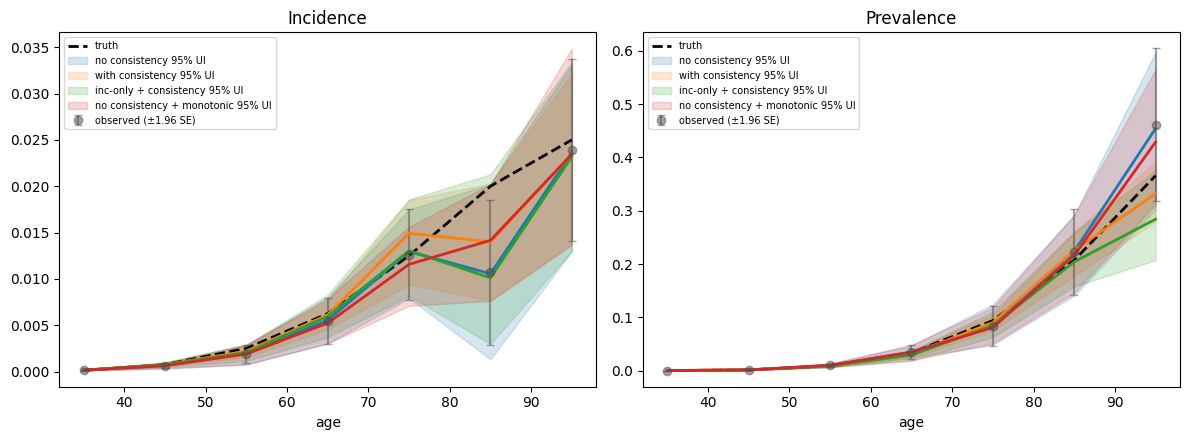

In [6]:
SERIES = [
    ("C0", "no consistency",         prev_no,       inc_no),
    ("C1", "with consistency",       prev_yes,      inc_yes),
    ("C2", "inc-only + consistency", prev_inc_only, inc_inc_only),
    ("C3", "no consistency + monotonic", prev_mono, inc_mono),
]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, (truth, obs, title, obs_se, prev_or_inc_idx) in zip(
    axes,
    [
        (true_inc,  obs_inc_1,  "Incidence",  obs_inc_se,  3),
        (true_prev, obs_prev_1, "Prevalence", obs_prev_se, 2),
    ],
):
    ax.errorbar(ages, obs, yerr=1.96*obs_se, fmt='o', color='0.3',
                alpha=0.5, capsize=3, label='observed (±1.96 SE)')
    ax.plot(ages, truth, 'k--', lw=2, label='truth')
    for color, label, prev_tuple, inc_tuple in SERIES:
        med, lo, hi = inc_tuple if prev_or_inc_idx == 3 else prev_tuple
        ax.fill_between(ages, lo, hi, alpha=0.18, color=color,
                        label=f'{label} 95% UI')
        ax.plot(ages, med, color=color, lw=2)
    ax.set_title(title); ax.set_xlabel('age')
    ax.legend(loc='upper left', fontsize=7)

plt.tight_layout(); plt.show()

## Monte Carlo replication

Now we repeat: draw a new noisy dataset, fit both models, record the
posterior median and 95% UI for each age.  After `N_REPS` replicates we
have enough samples to estimate bias, RMSE, and coverage.

> Part 2 is a small model, so each fit is fast — we use modest
> `num_warmup`/`num_samples` to keep the full loop well under the
> notebook cell-execution timeout.


In [7]:
N_REPS = 30
NUM_WARMUP = 120
NUM_SAMPLES = 120

MODELS = [
    ("no",       model_no_consistency),
    ("yes",      model_with_consistency),
    ("inc_only", model_inc_only_with_consistency),
    ("mono",     model_no_consistency_monotonic),
]

results = {
    tag: {"prev_med": [], "prev_lo": [], "prev_hi": [],
          "inc_med":  [], "inc_lo":  [], "inc_hi":  []}
    for tag, _ in MODELS
}
datasets = []

for rep in range(N_REPS):
    seed = 1000 + rep
    op, oi = simulate_dataset(seed)
    datasets.append((op, oi))

    for j, (tag, model_fn) in enumerate(MODELS):
        s = fit(model_fn, op, oi, seed=2000 + rep + j * 10000,
                num_warmup=NUM_WARMUP, num_samples=NUM_SAMPLES)
        for name in ("prev", "inc"):
            results[tag][f"{name}_med"].append(np.median(s[name], axis=0))
            results[tag][f"{name}_lo"].append(np.quantile(s[name], 0.025, axis=0))
            results[tag][f"{name}_hi"].append(np.quantile(s[name], 0.975, axis=0))

    if (rep + 1) % 5 == 0:
        print(f"  finished replicate {rep+1}/{N_REPS}")

for tag in results:
    for key in results[tag]:
        results[tag][key] = np.asarray(results[tag][key])
print("shape check:", results["no"]["prev_med"].shape, "(reps, ages)")

  finished replicate 5/30


  finished replicate 10/30


  finished replicate 15/30


  finished replicate 20/30


  finished replicate 25/30


  finished replicate 30/30
shape check: (30, 7) (reps, ages)


### Bias, RMSE and 95% UI coverage

For each age we compute:

- **bias** = mean over replicates of `(posterior_median − truth)`
- **RMSE** = sqrt(mean over replicates of `(posterior_median − truth)^2`)
- **coverage** = fraction of replicates where `lo ≤ truth ≤ hi`


In [8]:
def accuracy(med, lo, hi, truth):
    bias = np.mean(med - truth[None, :], axis=0)
    rmse = np.sqrt(np.mean((med - truth[None, :])**2, axis=0))
    cov  = np.mean((lo <= truth[None, :]) & (truth[None, :] <= hi), axis=0)
    return bias, rmse, cov

TAGS = ["no", "yes", "inc_only", "mono"]
TAG_LABELS = {"no": "no", "yes": "yes", "inc_only": "inc-only", "mono": "mono"}

metrics = {}
for tag in TAGS:
    metrics[tag] = {}
    for name, truth in [("prev", true_prev), ("inc", true_inc)]:
        b, r, c = accuracy(
            results[tag][f"{name}_med"],
            results[tag][f"{name}_lo"],
            results[tag][f"{name}_hi"],
            truth,
        )
        metrics[tag][name] = {"bias": b, "rmse": r, "coverage": c}

# Print a compact summary row-per-age
import pandas as pd
rows = []
for name, truth in [("prev", true_prev), ("inc", true_inc)]:
    for i, a in enumerate(ages):
        row = {"rate": name, "age": a, "truth": truth[i]}
        for metric in ("bias", "rmse", "cov"):
            key = "coverage" if metric == "cov" else metric
            for tag in TAGS:
                row[f"{metric} ({TAG_LABELS[tag]})"] = metrics[tag][name][key][i]
        rows.append(row)
pd.DataFrame(rows).round(4)

,rate,age,truth,bias (no),bias (yes),bias (inc-only),bias (mono),rmse (no),rmse (yes),rmse (inc-only),rmse (mono),cov (no),cov (yes),cov (inc-only),cov (mono)
0,prev,35,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,1.0000,1.0000
1,prev,45,0.0012,-0.0000,0.0000,0.0001,-0.0000,0.0002,0.0002,0.0003,0.0002,0.9333,0.8667,0.8333,0.9333
2,prev,55,0.0087,0.0002,0.0002,0.0002,0.0003,0.0021,0.0014,0.0017,0.0020,0.8667,0.8667,0.9000,0.9333
3,prev,65,0.0335,0.0022,0.0015,0.0010,0.0022,0.0067,0.0041,0.0043,0.0067,0.9333,0.9000,0.9667,0.9333
4,prev,75,0.0939,-0.0038,0.0009,0.0015,-0.0030,0.0203,0.0098,0.0138,0.0185,0.9000,0.9667,0.9000,0.9333
5,prev,85,0.2072,0.0108,0.0062,0.0048,0.0081,0.0405,0.0226,0.0251,0.0394,1.0000,0.8667,0.9333,0.9667
6,prev,95,0.3657,0.0024,0.0058,0.0052,-0.0184,0.0740,0.0286,0.0364,0.0671,0.9667,1.0000,0.9667,0.9333
7,inc,35,0.0001,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.8333,0.8667,0.8333,0.8667
8,inc,45,0.0008,-0.0000,0.0000,0.0000,-0.0000,0.0002,0.0001,0.0002,0.0002,0.8333,0.7667,0.9000,0.8000
9,inc,55,0.0025,-0.0000,0.0001,0.0001,-0.0000,0.0004,0.0004,0.0004,0.0004,1.0000,0.9000,0.9667,0.9667


### Summary plot — where does consistency help?

Bars show the difference between the two fitting strategies.  For bias
and RMSE lower is better; for coverage, closer to the nominal 0.95 is
better.


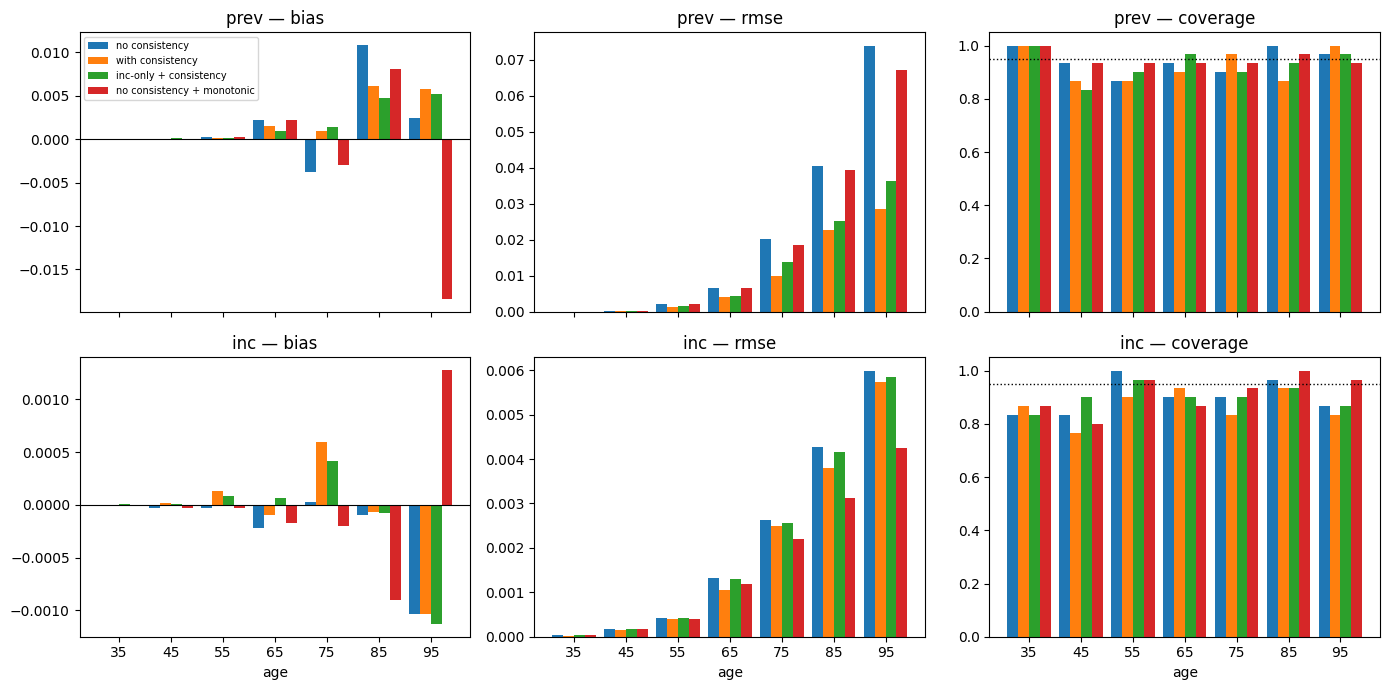

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharex=True)
x = np.arange(n_ages); width = 0.21
tag_info = [
    ("no",       "C0", "no consistency"),
    ("yes",      "C1", "with consistency"),
    ("inc_only", "C2", "inc-only + consistency"),
    ("mono",     "C3", "no consistency + monotonic"),
]

for row, (name, truth) in enumerate([("prev", true_prev), ("inc", true_inc)]):
    for col, metric in enumerate(["bias", "rmse", "coverage"]):
        ax = axes[row, col]
        for j, (tag, color, label) in enumerate(tag_info):
            offset = (j - 1.5) * width  # symmetric offsets for 4 bars
            v = metrics[tag][name][metric]
            ax.bar(x + offset, v, width, color=color, label=label)
        if metric == "coverage":
            ax.axhline(0.95, color='k', ls=':', lw=1, label='nominal 0.95')
            ax.set_ylim(0, 1.05)
        elif metric == "bias":
            ax.axhline(0.0, color='k', lw=0.8)
        ax.set_title(f"{name} — {metric}")
        ax.set_xticks(x); ax.set_xticklabels(ages)
        if row == 1: ax.set_xlabel('age')
        if row == 0 and col == 0: ax.legend(fontsize=7)

plt.tight_layout(); plt.show()

## A compelling GIF — metrics converging as replicates accumulate

The animation below has three blocks and compares four models:
**blue** = no-consistency, **orange** = with-consistency,
**green** = inc-only + consistency (prevalence data deliberately
dropped), **red** = no-consistency + monotonic (each rate forced to be
non-decreasing in age via a cumulative-increment reparameterisation,
but no tie between the two rates).  All four share the same hard
`prev[0] = 0` initial condition.

* **Top left**: the current replicate's fits (posterior medians + 95% UIs)
  for prevalence and incidence, plus the truth.
* **Top right**: running RMSE per age, *averaged across all replicates
  seen so far*.  The four-bar groups let you compare how quickly each
  model's RMSE settles.  Comparing red (monotonic only) with orange
  (full consistency) isolates how much of consistency's benefit comes
  from tying the two rates together vs. just shape smoothing within
  each curve.
* **Bottom row (small multiples, one panel per age)**: scatter of the
  posterior-median **incidence** vs posterior-median **prevalence**
  across every replicate seen so far.  The black *x* marks the truth.
  This makes the coupling induced by different constraints visible
  age-by-age.

We save the animation as a GIF in this directory so it can be embedded
in slides.

In [10]:
from matplotlib.animation import FuncAnimation, PillowWriter

TAGS_COLORS_LABELS = [
    ("no",       "C0", "no consistency"),
    ("yes",      "C1", "with consistency"),
    ("inc_only", "C2", "inc-only + consistency"),
    ("mono",     "C3", "no consistency + monotonic"),
]

def running_rmse(tag, name, truth, upto):
    med = results[tag][f"{name}_med"][:upto+1]
    return np.sqrt(np.mean((med - truth[None, :])**2, axis=0))

# --- Pre-compute y-axis ranges so the axes don't jump frame-to-frame ---
def _ylim(values, pad=0.10, floor=0.0):
    lo = min(floor, float(np.min(values)))
    hi = float(np.max(values))
    if hi == lo:
        hi = lo + 1e-3
    return (lo, hi + pad * (hi - lo))

# Left panels need room for the widest of: truth, observed + 1.96*SE, and the
# outermost posterior UI bound across every replicate in all four fits.
prev_upper = np.concatenate([
    [true_prev.max()],
    (true_prev + 1.96 * obs_prev_se),
    *[results[t]["prev_hi"].ravel() for t, _, _ in TAGS_COLORS_LABELS],
])
prev_lower = np.concatenate([
    *[results[t]["prev_lo"].ravel() for t, _, _ in TAGS_COLORS_LABELS],
])
inc_upper = np.concatenate([
    [true_inc.max()],
    (true_inc + 1.96 * obs_inc_se),
    *[results[t]["inc_hi"].ravel() for t, _, _ in TAGS_COLORS_LABELS],
])
inc_lower = np.concatenate([
    *[results[t]["inc_lo"].ravel() for t, _, _ in TAGS_COLORS_LABELS],
])

YLIM_PREV = _ylim(np.concatenate([prev_lower, prev_upper]))
YLIM_INC  = _ylim(np.concatenate([inc_lower,  inc_upper]))

# Right panels: running RMSE is non-negative; take the largest running RMSE
# across *all* prefixes so bar heights never overflow the axis.
def _max_running_rmse(name, truth):
    return max(
        running_rmse(tag, name, truth, r).max()
        for tag, _, _ in TAGS_COLORS_LABELS
        for r in range(N_REPS)
    )
YLIM_RMSE_PREV = (0.0, _max_running_rmse("prev", true_prev) * 1.10 + 1e-6)
YLIM_RMSE_INC  = (0.0, _max_running_rmse("inc",  true_inc)  * 1.10 + 1e-6)

# Scatter-row (per-age) axis limits -- fixed so the clouds don't rescale as
# they accumulate.  Uses posterior medians from every replicate + truth.
SCATTER_XLIM, SCATTER_YLIM = [], []
for k in range(n_ages):
    xs = np.concatenate([
        *[results[t]["inc_med"][:, k] for t, _, _ in TAGS_COLORS_LABELS],
        [true_inc[k]],
    ])
    ys = np.concatenate([
        *[results[t]["prev_med"][:, k] for t, _, _ in TAGS_COLORS_LABELS],
        [true_prev[k]],
    ])
    SCATTER_XLIM.append(_ylim(xs, pad=0.20))
    SCATTER_YLIM.append(_ylim(ys, pad=0.20))


fig = plt.figure(figsize=(14, 9.5))
gs = fig.add_gridspec(3, n_ages, height_ratios=[2, 2, 1.5], hspace=0.55, wspace=0.45)

# Top two rows keep the existing 2x2 layout by spanning the 7 scatter columns.
split = n_ages // 2 + 1  # 4 columns for the line plot, 3 for running RMSE
ax_inc       = fig.add_subplot(gs[0, :split])
ax_rmse_inc  = fig.add_subplot(gs[0, split:])
ax_prev      = fig.add_subplot(gs[1, :split])
ax_rmse_prev = fig.add_subplot(gs[1, split:])
scatter_axes = [fig.add_subplot(gs[2, k]) for k in range(n_ages)]
line_axes = [ax_inc, ax_rmse_inc, ax_prev, ax_rmse_prev]


def _tuples(name, rep_idx):
    """Return (med, lo, hi) for each tag at this replicate, in TAGS order."""
    return [
        (results[tag][f"{name}_med"][rep_idx],
         results[tag][f"{name}_lo"][rep_idx],
         results[tag][f"{name}_hi"][rep_idx])
        for tag, _, _ in TAGS_COLORS_LABELS
    ]


def draw_frame(rep_idx):
    for ax in line_axes + scatter_axes:
        ax.clear()

    op, oi = datasets[rep_idx]

    # --- Top block, left column: this replicate's fits (all four models) ---
    for ax, truth, obs, se, tuples, title, ylim in [
        (ax_prev, true_prev, op, obs_prev_se, _tuples("prev", rep_idx),
         "Prevalence — this replicate", YLIM_PREV),
        (ax_inc,  true_inc,  oi, obs_inc_se,  _tuples("inc",  rep_idx),
         "Incidence — this replicate",  YLIM_INC),
    ]:
        ax.errorbar(ages, obs, yerr=1.96*se, fmt='o', color='0.3',
                    alpha=0.5, capsize=3)
        ax.plot(ages, truth, 'k--', lw=2, label='truth')
        for (med, lo, hi), (_, color, label) in zip(tuples, TAGS_COLORS_LABELS):
            ax.fill_between(ages, lo, hi, alpha=0.15, color=color)
            ax.plot(ages, med, color=color, lw=2, label=label)
        ax.set_title(title); ax.set_xlabel('age')
        ax.set_ylim(ylim)
        ax.legend(loc='upper left', fontsize=7)

    # --- Top block, right column: running RMSE (all four models) ---
    x = np.arange(n_ages); width = 0.21
    for ax, name, truth, title, ylim in [
        (ax_rmse_prev, "prev", true_prev, "Running RMSE (prevalence)", YLIM_RMSE_PREV),
        (ax_rmse_inc,  "inc",  true_inc,  "Running RMSE (incidence)",  YLIM_RMSE_INC),
    ]:
        for j, (tag, color, _) in enumerate(TAGS_COLORS_LABELS):
            offset = (j - 1.5) * width  # symmetric offsets for 4 bars
            r = running_rmse(tag, name, truth, rep_idx)
            ax.bar(x + offset, r, width, color=color)
        ax.set_title(title); ax.set_xticks(x); ax.set_xticklabels(ages)
        ax.set_xlabel('age')
        ax.set_ylim(ylim)

    # --- Bottom row: per-age scatter of posterior-median (inc, prev) ---
    # One point per replicate seen so far, per model.  The four clouds let
    # you see how each fitting strategy couples the two rates age-by-age.
    for k, ax in enumerate(scatter_axes):
        for tag, color, label in TAGS_COLORS_LABELS:
            xs = results[tag]["inc_med"][:rep_idx+1, k]
            ys = results[tag]["prev_med"][:rep_idx+1, k]
            ax.scatter(xs, ys, s=14, color=color, alpha=0.55,
                       edgecolor='none', label=(label if k == 0 else None))
        ax.plot(true_inc[k], true_prev[k], 'kx', ms=9, mew=2)
        ax.set_title(f"age {ages[k]}", fontsize=9)
        ax.set_xlim(SCATTER_XLIM[k])
        ax.set_ylim(SCATTER_YLIM[k])
        ax.tick_params(labelsize=7)
        if k == 0:
            ax.set_ylabel("prev median", fontsize=8)
            ax.legend(loc='upper left', fontsize=6, framealpha=0.8)
        ax.set_xlabel("inc median", fontsize=8)

    fig.suptitle(
        f"replicate {rep_idx+1}/{N_REPS} — bottom row: per-age (inc, prev) scatter",
        y=0.995, fontsize=12,
    )

anim = FuncAnimation(fig, draw_frame, frames=N_REPS, interval=400)

gif_path = "consistent_fit_accuracy.gif"
anim.save(gif_path, writer=PillowWriter(fps=2.5))
plt.close(fig)
print("wrote", gif_path)

wrote consistent_fit_accuracy.gif


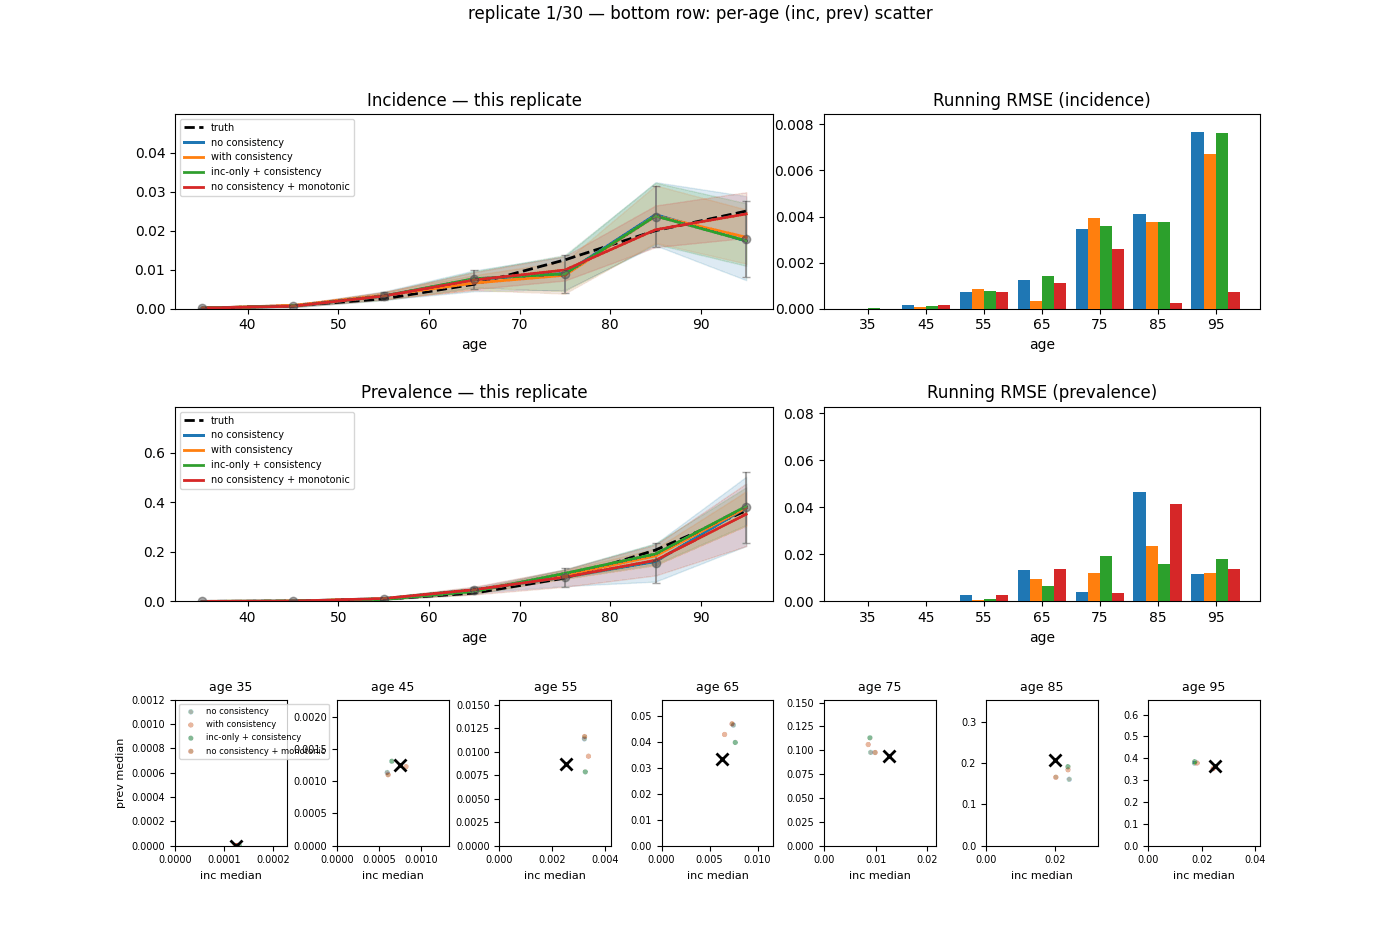

In [11]:
from IPython.display import Image
Image(filename="consistent_fit_accuracy.gif")


## Take-aways

* The consistency factor **propagates information between prev and
  inc**: a noisy incidence observation gets pulled toward values that
  are compatible with the neighbouring prevalences, and vice versa.
  In this setup that translates into **lower RMSE** (particularly at
  the ages where one of the rates is poorly measured relative to the
  other) without wrecking coverage.
* All four models start from the same `prev[0] = 0` initial
  condition.  With that anchor the inc-only model (green) can step
  the difference equation forward to reconstruct a plausible
  prevalence curve even though no prevalence data are observed.
* The monotonic-only model (red) tests whether a plain within-curve
  smoothness constraint can stand in for the consistency factor.
  Monotonicity alone clearly reduces RMSE relative to the
  un-constrained fit (blue), but it does not match the full
  consistency model (orange) — tying the two rates together through
  the difference equation squeezes more information out of the same
  observations than either rate's individual shape constraint does.
* The inc-only model recovers **incidence** about as well as the
  two-observation models, showing that the consistency factor does
  not distort inference for the quantity that actually has data.

This is the same mechanism that operates inside the full
`consistent_rates.py` ODE — only there the "prediction" comes from
`diffeqsolve` over a 5-compartment system rather than the
two-line update we used in Part 2.